<a href="https://colab.research.google.com/github/chevalier08/CST3390-Individual-Project/blob/main/EV_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

Upload dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DATA.xlsx to DATA.xlsx


Load data

In [ ]:
import pandas as pd

df = pd.read_excel("DATA.xlsx")

# 2. Exploratory Data Analysis

In [ ]:
df.head() #Displays the first 5 rows of the dataset

,date_and_time,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C),is_holiday,day_type
0,2020.1.1 1:00,64007,3200,805,-5.2,53.7,-4.0,True,weekday
1,2020.1.1 2:00,61534,2320,791,-5.2,55.4,-3.9,True,weekday
2,2020.1.1 3:00,59447,1600,259,-5.1,57.1,-3.8,True,weekday
3,2020.1.1 4:00,58163,1520,84,-4.9,59.4,-3.5,True,weekday
4,2020.1.1 5:00,57884,2240,91,-4.3,61.1,-3.2,True,weekday


In [ ]:
df.tail() #Displays the last 5 rows of the dataset

,date_and_time,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C),is_holiday,day_type
35035,2023.12.30 20:00,64934,10960,1883,4.3,87.8,3.4,False,weekend
35036,2023.12.30 21:00,63817,9600,1876,4.3,89.0,3.4,False,weekend
35037,2023.12.30 22:00,62436,8240,1813,4.4,89.2,3.4,False,weekend
35038,2023.12.30 23:00,63010,4960,1757,4.5,90.1,3.5,False,weekend
35039,2023.12.31 0:00,62981,4480,889,4.6,91.2,3.6,False,weekend


In [ ]:
df.info() #Provides a summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date_and_time           35040 non-null  object 
 1   power_demand_MWh        35040 non-null  int64  
 2   EV_fast_charging        35040 non-null  int64  
 3   EV_slow_charging        35040 non-null  int64  
 4   temperature(°C)         34968 non-null  float64
 5   humidity(%)             34968 non-null  float64
 6   ground_temperature(°C)  34968 non-null  float64
 7   is_holiday              35040 non-null  bool   
 8   day_type                35040 non-null  object 
dtypes: bool(1), float64(3), int64(3), object(2)
memory usage: 2.2+ MB


In [ ]:
df.describe() #Generates descriptive statistics of the dataset

,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C)
count,35040.000000,35040.000000,35040.000000,34968.000000,34968.000000,34968.000000
mean,63786.773830,11010.853881,1221.053910,13.544521,70.080891,15.640674
std,9397.286394,8064.906541,933.766863,9.792954,17.708243,11.798276
min,38422.000000,160.000000,14.000000,-15.100000,16.300000,-8.100000
25%,56853.000000,4040.000000,441.000000,5.700000,57.500000,5.500000
50%,62900.000000,9440.000000,1015.000000,14.400000,72.500000,15.900000
75%,69730.250000,16400.000000,1848.000000,22.000000,85.300000,24.600000
max,94509.000000,59040.000000,4662.000000,33.700000,98.000000,52.600000


Check for missing values

In [ ]:
df.isnull().sum() #Count missing values per column

,0
date_and_time,0
power_demand_MWh,0
EV_fast_charging,0
EV_slow_charging,0
temperature(°C),72
humidity(%),72
ground_temperature(°C),72
is_holiday,0
day_type,0


In [ ]:
(df.isnull().sum() / len(df)) * 100 #Missing values as % of total rows

,0
date_and_time,0.000000
power_demand_MWh,0.000000
EV_fast_charging,0.000000
EV_slow_charging,0.000000
temperature(°C),0.205479
humidity(%),0.205479
ground_temperature(°C),0.205479
is_holiday,0.000000
day_type,0.000000


# 3. Data Pre-Processing

Data imputation

In [ ]:
df.columns #Inspect column names before pre-processing

Index(['date_and_time', 'power_demand_MWh', 'EV_fast_charging',
       'EV_slow_charging', 'temperature(°C)', 'humidity(%)',
       'ground_temperature(°C)', 'is_holiday', 'day_type'],
      dtype='object')

In [ ]:
df['date_and_time'] = pd.to_datetime(df['date_and_time'])
df = df.set_index('date_and_time')
df[['temperature(°C)', 'ground_temperature(°C)', 'humidity(%)']] = \
df[['temperature(°C)', 'ground_temperature(°C)', 'humidity(%)']].interpolate(method='time') #Applying the interpolation method

In [ ]:
print(df.columns) #Confirm columns after setting datetime index

Index(['power_demand_MWh', 'EV_fast_charging', 'EV_slow_charging',
       'temperature(°C)', 'humidity(%)', 'ground_temperature(°C)',
       'is_holiday', 'day_type'],
      dtype='object')


In [ ]:
df.rename(columns={'date_and _time':'date_and_time'}, inplace=True) #Fix typo in column name

In [ ]:
df.isnull().sum() #Checking sum of null values in each column

,0
power_demand_MWh,0
EV_fast_charging,0
EV_slow_charging,0
temperature(°C),0
humidity(%),0
ground_temperature(°C),0
is_holiday,0
day_type,0


In [ ]:
df = pd.get_dummies(df, columns=['day_type', 'is_holiday'], drop_first=True) #One-hot Encoding categorical variables

In [ ]:
df.head() #Preview after one-hot encoding

,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C),day_type_weekend,is_holiday_True
date_and_time,,,,,,,,
2020-01-01 01:00:00,64007,3200,805,-5.2,53.7,-4.0,False,True
2020-01-01 02:00:00,61534,2320,791,-5.2,55.4,-3.9,False,True
2020-01-01 03:00:00,59447,1600,259,-5.1,57.1,-3.8,False,True
2020-01-01 04:00:00,58163,1520,84,-4.9,59.4,-3.5,False,True
2020-01-01 05:00:00,57884,2240,91,-4.3,61.1,-3.2,False,True


In [ ]:
df['day_type_weekend'] = df['day_type_weekend'].astype(int) #Converting from Boolean type to Integer type
df['is_holiday_True'] = df['is_holiday_True'].astype(int)

In [ ]:
df.head()

,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C),day_type_weekend,is_holiday_True
date_and_time,,,,,,,,
2020-01-01 01:00:00,64007,3200,805,-5.2,53.7,-4.0,0,1
2020-01-01 02:00:00,61534,2320,791,-5.2,55.4,-3.9,0,1
2020-01-01 03:00:00,59447,1600,259,-5.1,57.1,-3.8,0,1
2020-01-01 04:00:00,58163,1520,84,-4.9,59.4,-3.5,0,1
2020-01-01 05:00:00,57884,2240,91,-4.3,61.1,-3.2,0,1


In [ ]:
df.tail()

,power_demand_MWh,EV_fast_charging,EV_slow_charging,temperature(°C),humidity(%),ground_temperature(°C),day_type_weekend,is_holiday_True
date_and_time,,,,,,,,
2023-12-30 20:00:00,64934,10960,1883,4.3,87.8,3.4,1,0
2023-12-30 21:00:00,63817,9600,1876,4.3,89.0,3.4,1,0
2023-12-30 22:00:00,62436,8240,1813,4.4,89.2,3.4,1,0
2023-12-30 23:00:00,63010,4960,1757,4.5,90.1,3.5,1,0
2023-12-31 00:00:00,62981,4480,889,4.6,91.2,3.6,1,0


Stationarity Check (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['power_demand_MWh'])

print("p-value:", result[1])

p-value: 2.4739935924598156e-28


In [ ]:
df = df.rename(columns={ #Renaming columns
    'power_demand(MWh)': 'power_demand_MWh',
    'temperature(°C)': 'temperature_c',
    'ground_temperature(°C)': 'ground_temperature_c',
    'humidity(%)': 'humidity_pct'
})

In [ ]:
df.columns #Confirm renamed columns

Index(['power_demand_MWh', 'EV_fast_charging', 'EV_slow_charging',
       'temperature_c', 'humidity_pct', 'ground_temperature_c',
       'day_type_weekend', 'is_holiday_True'],
      dtype='object')

# 4. Modelling

## SARIMAX

Scenario A -- Without EV Charging Variables

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Without EV - MAE: 12844.93375068533
Without EV - RMSE: 15270.556675404932
Without EV - MAPE: 21.25%


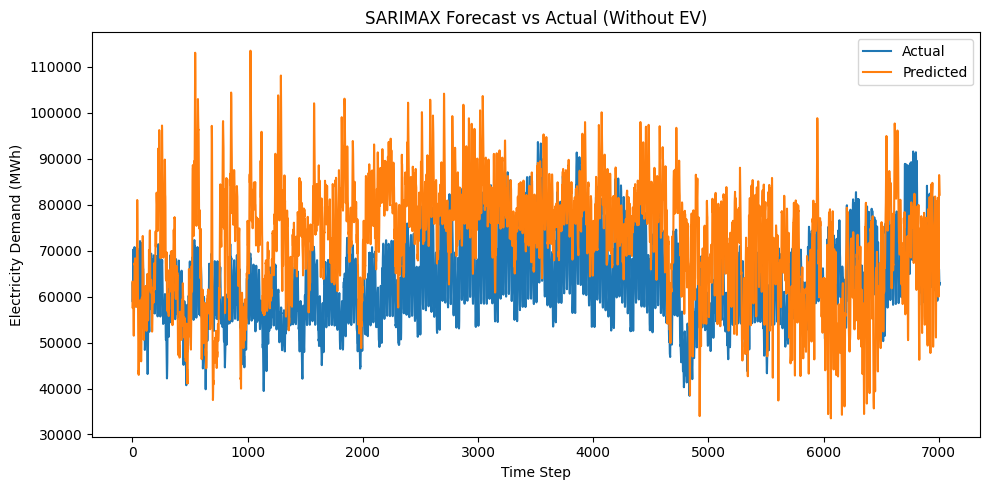

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y = df['power_demand_MWh'] #Defining target variable

X_noEV = df.drop(columns=[ #Excluding EV charging variables
    'power_demand_MWh',
    'EV_fast_charging',
    'EV_slow_charging'
])

train_size = int(len(df) * 0.8) #80% training size

# Target
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

# Without EV
X_train_noEV = X_noEV.iloc[:train_size]
X_test_noEV  = X_noEV.iloc[train_size:]


# Model 1: Without EV
model_noEV = SARIMAX(y_train,
                     exog=X_train_noEV,
                     order=(1,0,1),
                     seasonal_order=(1,0,1,24),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

results_noEV = model_noEV.fit()

forecast_noEV = results_noEV.predict(start=len(y_train),
                                     end=len(y_train)+len(y_test)-1,
                                     exog=X_test_noEV)

# Error metrics
mae_noEV = mean_absolute_error(y_test, forecast_noEV)
rmse_noEV = np.sqrt(mean_squared_error(y_test, forecast_noEV))
mape_noEV = np.mean(np.abs((y_test - forecast_noEV) / y_test)) * 100

print("Without EV - MAE:", mae_noEV)
print("Without EV - RMSE:", rmse_noEV)
print("Without EV - MAPE: {:.2f}%".format(mape_noEV))

# Prediction vs Actual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(forecast_noEV.values, label="Predicted")

plt.title("SARIMAX Forecast vs Actual (Without EV)")
plt.xlabel("Time Step")
plt.ylabel("Electricity Demand (MWh)")
plt.legend()
plt.tight_layout()
plt.show()

Scenario B -- With EV Charging Variables

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


With EV - MAE: 8254.700083501732
With EV - RMSE: 10277.556413848262
With EV - MAPE: 13.23%


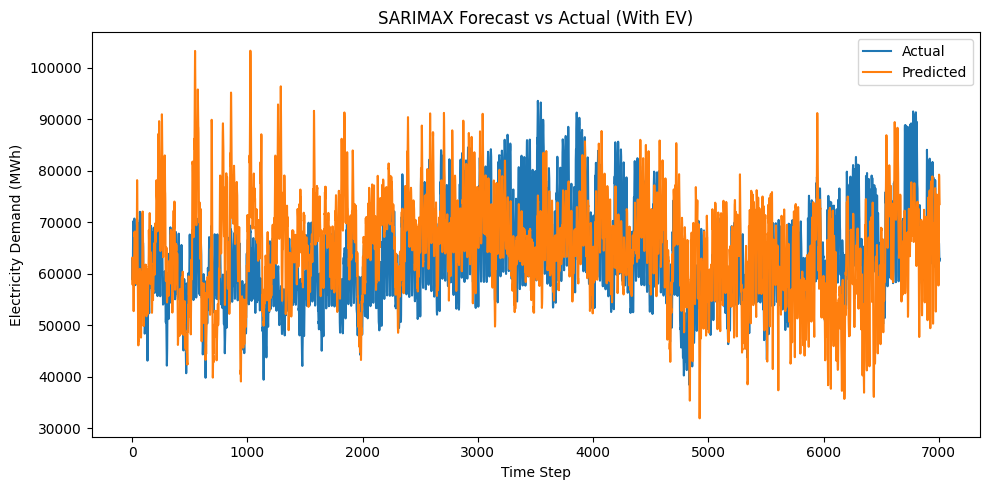

In [ ]:
X_withEV = df.drop(columns=['power_demand_MWh'])
train_size = int(len(df) * 0.8)

# Target
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

# With EV
X_train_withEV = X_withEV.iloc[:train_size]
X_test_withEV  = X_withEV.iloc[train_size:]

from statsmodels.tsa.statespace.sarimax import SARIMAX
model_withEV = SARIMAX(y_train,
                       exog=X_train_withEV,
                       order=(1,0,1),
                       seasonal_order=(1,0,1,24),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_withEV = model_withEV.fit()

forecast_withEV = results_withEV.predict(start=len(y_train),
                                         end=len(y_train)+len(y_test)-1,
                                         exog=X_test_withEV)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_withEV = mean_absolute_error(y_test, forecast_withEV)
rmse_withEV = np.sqrt(mean_squared_error(y_test, forecast_withEV))
mape_withEV = np.mean(np.abs((y_test - forecast_withEV) / y_test)) * 100

print("With EV - MAE:", mae_withEV)
print("With EV - RMSE:", rmse_withEV)
print("With EV - MAPE: {:.2f}%".format(mape_withEV))

# Prediction vs Actual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(forecast_withEV.values, label="Predicted")

plt.title("SARIMAX Forecast vs Actual (With EV)")
plt.xlabel("Time Step")
plt.ylabel("Electricity Demand (MWh)")
plt.legend()
plt.tight_layout()
plt.show()

## SVR (Support Vector Regression)

Scenario A - Without EV Charging Variables

SVR WITHOUT EV
MAE: 4654.613147890337
RMSE: 6126.893098267192
MAPE: 7.242748174077889


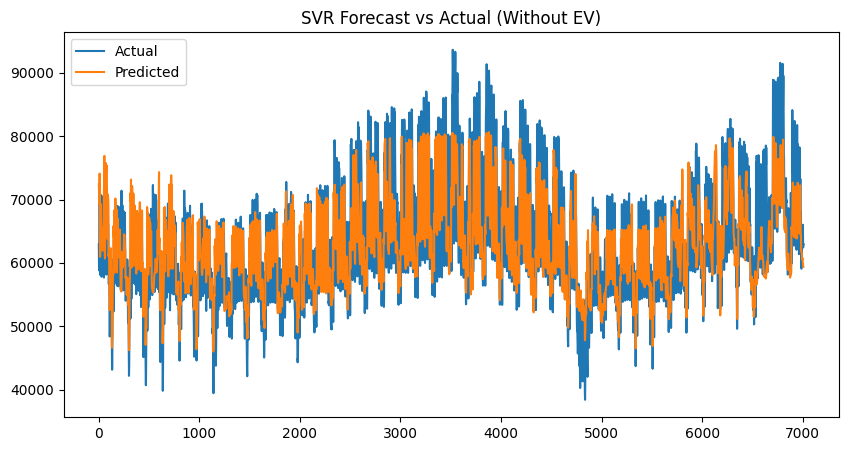

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. DEFINE X AND y
X = df.drop(columns=['power_demand_MWh', 'EV_slow_charging', 'EV_fast_charging'])
y = df['power_demand_MWh']

# 2. SIMPLE SPLIT
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# 3. SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SVR
svr = SVR(
    kernel='rbf',
    C=100,
    gamma=0.5,
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

# 5. PREDICT
pred = svr.predict(X_test_scaled)

# 6. METRICS
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("SVR WITHOUT EV")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# 7. PLOT
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("SVR Forecast vs Actual (Without EV)")
plt.legend()
plt.show()

Scenario B - With EV Charging Variables

SVR WITH EV
MAE: 3195.105883009952
RMSE: 4357.093307649714
MAPE: 5.133704427221677


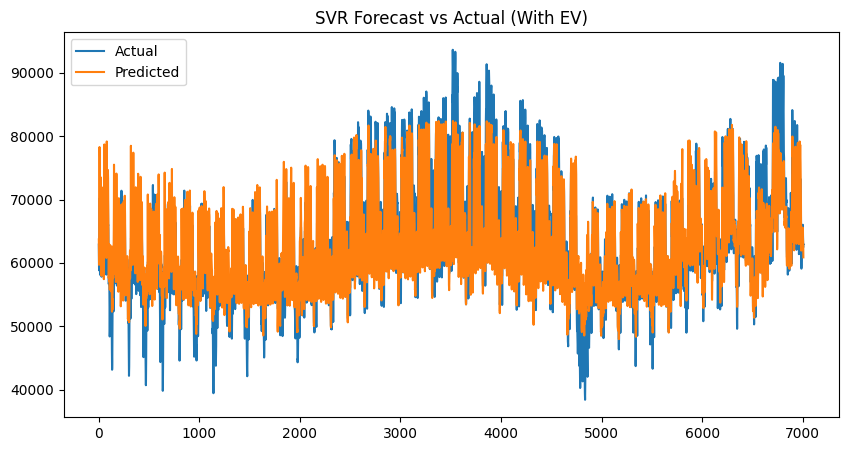

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. DEFINE X AND y
X = df.drop(columns=['power_demand_MWh'])
y = df['power_demand_MWh']

# 3. SIMPLE SPLIT
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# 4. SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. SVR
svr = SVR(
    kernel='rbf',
    C=100,
    gamma=0.5,
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

# 6. PREDICT
pred = svr.predict(X_test_scaled)

# 7. METRICS
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("SVR WITH EV")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# 8. PLOT
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("SVR Forecast vs Actual (With EV)")
plt.legend()
plt.show()

## LSTM (Long Short-Term Memory)

Scenario A - Without EV Charging Variables

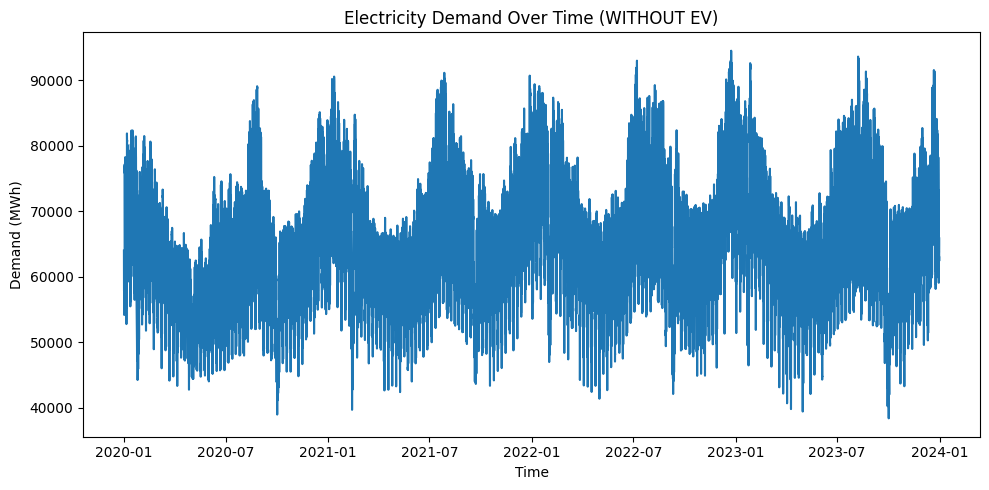

Scaled data sample:
[[0.20286885 0.45777234 0.0675453  0.         1.         0.45616631]
 [0.20286885 0.47858017 0.06919275 0.         1.         0.4120741 ]
 [0.20491803 0.499388   0.0708402  0.         1.         0.37486405]
 [0.20901639 0.52753978 0.07578254 0.         1.         0.35197104]
 [0.22131148 0.54834761 0.08072488 0.         1.         0.34699663]]
X shape: (35016, 24, 5)
y shape: (35016,)

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 0.0108 - val_loss: 0.0053
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0029 - val_loss: 0.0033
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 9/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 10/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0025 - val_loss: 0.0024


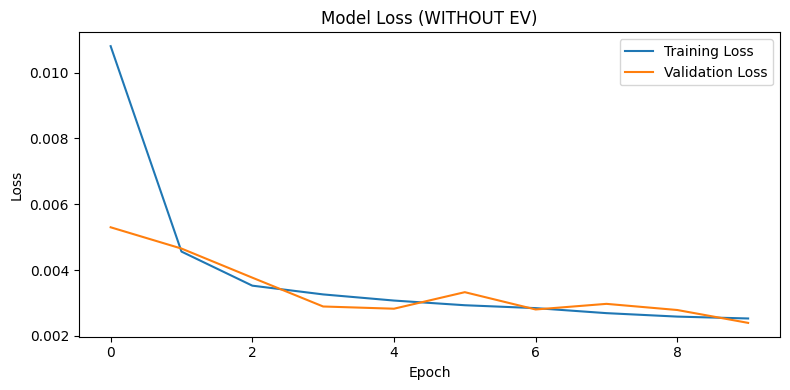

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

LSTM WITHOUT EV
MAE: 2062.475080461349
RMSE: 2745.386693600044
MAPE: 3.267097809010968


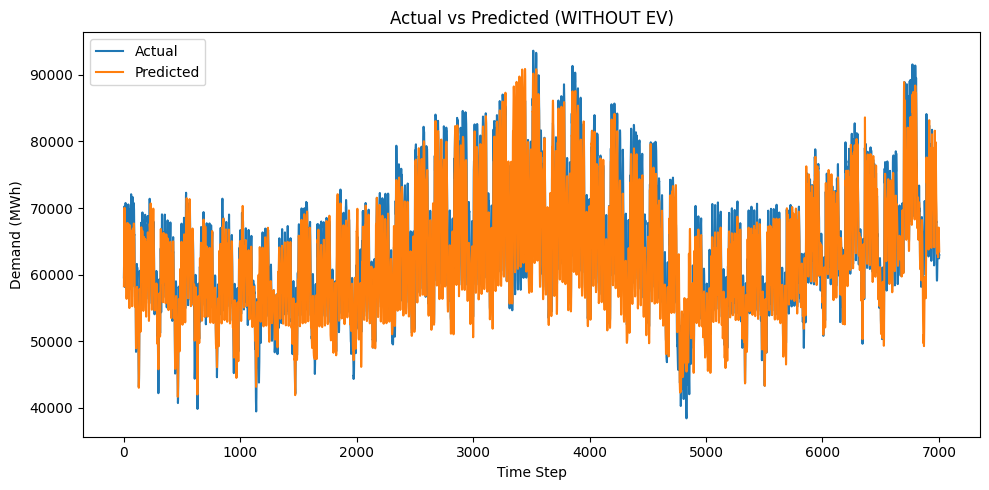


Sample Results:
    Actual     Predicted
0  59580.0  58256.039478
1  61213.0  60000.293636
2  64661.0  62593.995652
3  68504.0  65826.598833
4  70225.0  69666.626735
5  68628.0  70029.862024
6  66653.0  66287.330707
7  62617.0  62717.773591
8  58139.0  61255.914861
9  59664.0  61736.999197


In [ ]:
# ---------- 1. Import libraries ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ---------- 2. Select features ----------
features = ['temperature_c', 'humidity_pct', 'ground_temperature_c',
            'day_type_weekend', 'is_holiday_True']

target = 'power_demand_MWh'

df_A = df[features + [target]].copy()

# ---------- 3. Visualise target ----------
plt.figure(figsize=(10, 5))
plt.plot(df.index, df[target])
plt.title("Electricity Demand Over Time (WITHOUT EV)")
plt.xlabel("Time")
plt.ylabel("Demand (MWh)")
plt.tight_layout()
plt.show()

# ---------- 4. Scale data ----------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_A)

print("Scaled data sample:")
print(scaled_data[:5])

# ---------- 5. Create sequences ----------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step, :-1])
        y.append(data[i + time_step, -1])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ---------- 6. Train-test split ----------
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ---------- 7. Build model ----------
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step, X.shape[2])))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

print("\nModel Summary:")
model.summary()

# ---------- 8. Train ----------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ---------- 9. Plot training loss ----------
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss (WITHOUT EV)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 10. Predictions ----------
predictions = model.predict(X_test)

# ---------- 11. Inverse scaling ----------
temp = np.zeros((len(predictions), scaled_data.shape[1]))
temp[:, -1] = predictions.flatten()
predictions = scaler.inverse_transform(temp)[:, -1]

temp[:, -1] = y_test
y_test_actual = scaler.inverse_transform(temp)[:, -1]

# ---------- 12. Metrics ----------
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\nLSTM WITHOUT EV")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# ---------- 13. Plot predictions ----------
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Actual vs Predicted (WITHOUT EV)")
plt.xlabel("Time Step")
plt.ylabel("Demand (MWh)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 14. Results table ----------
results_df = pd.DataFrame({
    "Actual": y_test_actual,
    "Predicted": predictions
})

print("\nSample Results:")
print(results_df.head(10))

Scenario B - With EV Charging Variables

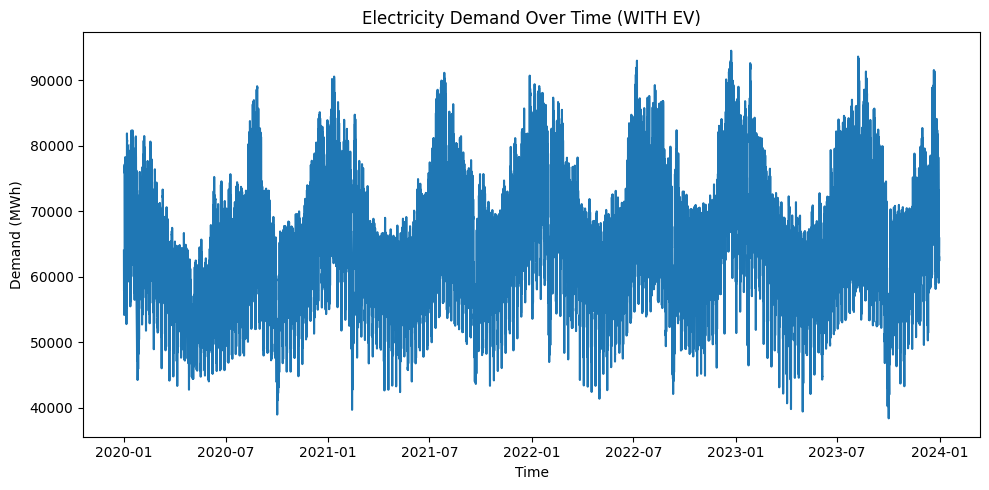


Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 50)         │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,851 (124.42 KB)

 Trainable params: 31,851 (124.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.0084 - val_loss: 0.0041
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0021 - val_loss: 0.0031
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0019 - val_loss: 0.0025
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 9/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 10/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0014 - val_loss: 0.0017


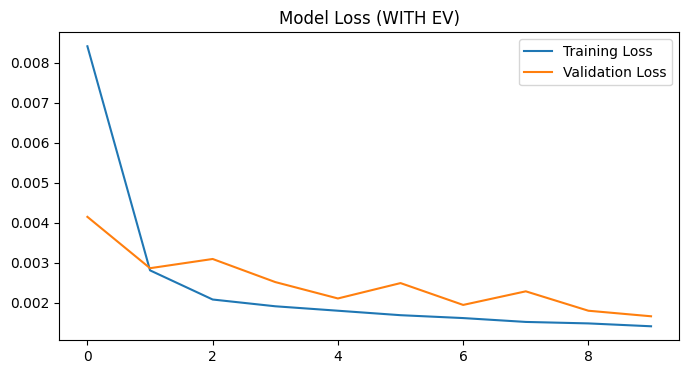

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

LSTM WITH EV
MAE: 1594.2445221016171
RMSE: 2289.2048204219286
MAPE: 2.556055547816304


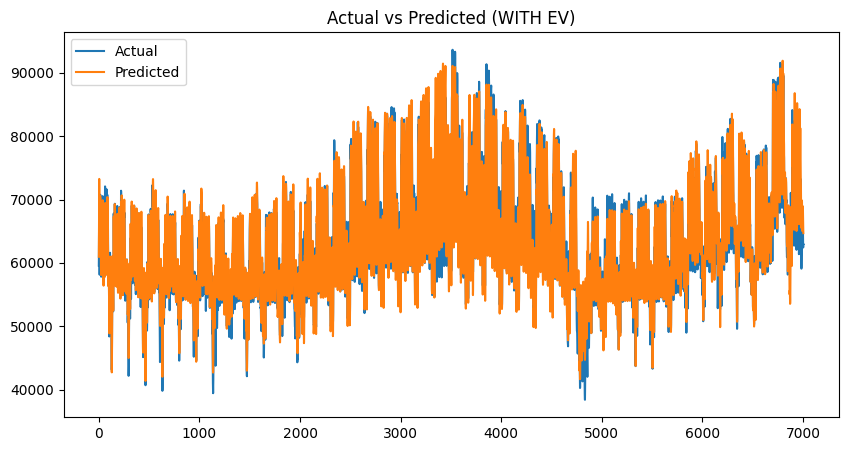

    Actual     Predicted
0  59580.0  60977.133265
1  61213.0  62776.464101
2  64661.0  66013.526906
3  68504.0  70601.282141
4  70225.0  73246.206303
5  68628.0  71437.284268
6  66653.0  66862.764151
7  62617.0  62933.408397
8  58139.0  61224.978316
9  59664.0  62316.009700


In [ ]:

# ---------- 1. Select features ----------
features = ['EV_fast_charging', 'EV_slow_charging',
            'temperature_c', 'humidity_pct', 'ground_temperature_c',
            'day_type_weekend', 'is_holiday_True']

target = 'power_demand_MWh'

df_B = df[features + [target]].copy()

# ---------- 2. Visualise ----------
plt.figure(figsize=(10, 5))
plt.plot(df.index, df[target])
plt.title("Electricity Demand Over Time (WITH EV)")
plt.xlabel("Time")
plt.ylabel("Demand (MWh)")
plt.tight_layout()
plt.show()

# ---------- 3. Scale ----------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_B)

# ---------- 4. Create sequences ----------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step, :-1])
        y.append(data[i + time_step, -1])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

# ---------- 5. Split ----------
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ---------- 6. Model ----------
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, X.shape[2])))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

print("\nModel Summary:")
model.summary()

# ---------- 7. Train ----------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ---------- 8. Loss plot ----------
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss (WITH EV)")
plt.legend()
plt.show()

# ---------- 9. Predictions ----------
predictions = model.predict(X_test)

# ---------- 10. Inverse scaling ----------
temp = np.zeros((len(predictions), scaled_data.shape[1]))
temp[:, -1] = predictions.flatten()
predictions = scaler.inverse_transform(temp)[:, -1]

temp[:, -1] = y_test
y_test_actual = scaler.inverse_transform(temp)[:, -1]

# ---------- 11. Metrics ----------
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\nLSTM WITH EV")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# ---------- 12. Plot ----------
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Actual vs Predicted (WITH EV)")
plt.legend()
plt.show()

# ---------- 13. Table ----------
results_df = pd.DataFrame({
    "Actual": y_test_actual,
    "Predicted": predictions
})

print(results_df.head(10))